In [109]:
import numpy as np
import pandas as pd
from scipy import stats 
from scipy import optimize
from scipy import *
import pingouin as pg
import janitor
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

avacado = pd.read_csv("C:/Users/nmesoma/Downloads/avocado.csv")
avacado.head(20)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
5,5,11/22/2015,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany
6,6,11/15/2015,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany
7,7,11/8/2015,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany
8,8,11/1/2015,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany
9,9,10/25/2015,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany


In [110]:
avacado1= avacado.clean_names()
avacado1.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [111]:
avacado1["date"]= pd.to_datetime(avacado1["date"])
avacado1.head()

,unnamed_0,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [112]:
avacado1.drop(columns=["unnamed_0"], inplace=True)
avacado1.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [113]:
avacado1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          18249 non-null  datetime64[ns]
 1   averageprice  18249 non-null  float64       
 2   total_volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   total_bags    18249 non-null  float64       
 7   small_bags    18249 non-null  float64       
 8   large_bags    18249 non-null  float64       
 9   xlarge_bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB


In [114]:
avacado1.describe()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,year
count,18249,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,2016-08-13 23:30:43.498273792,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
min,2015-01-04 00:00:00,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,2015-10-25 00:00:00,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,2016-08-14 00:00:00,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,2017-06-04 00:00:00,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,2018-03-25 00:00:00,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000
std,NaN,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938


In [115]:
 avacado1.isna().sum()

date            0
averageprice    0
total_volume    0
4046            0
4225            0
4770            0
total_bags      0
small_bags      0
large_bags      0
xlarge_bags     0
type            0
year            0
region          0
dtype: int64

In [116]:
avacado1["region"].nunique()

54

In [117]:
avacado_2= avacado1.copy()
avacado_2["type_binary"]=avacado_2["type"].map({"conventional": 0, "organic": 1})

In [118]:
avacado_2.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,type_binary
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,0
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,0
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,0
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,0
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,0


In [119]:
corr= avacado_2.corr(numeric_only = True)["averageprice"].sort_values(ascending=False)
corr
#

averageprice    1.000000
type_binary     0.615845
year            0.093197
xlarge_bags    -0.117592
4225           -0.172928
large_bags     -0.172940
small_bags     -0.174730
total_bags     -0.177088
4770           -0.179446
total_volume   -0.192752
4046           -0.208317
Name: averageprice, dtype: float64

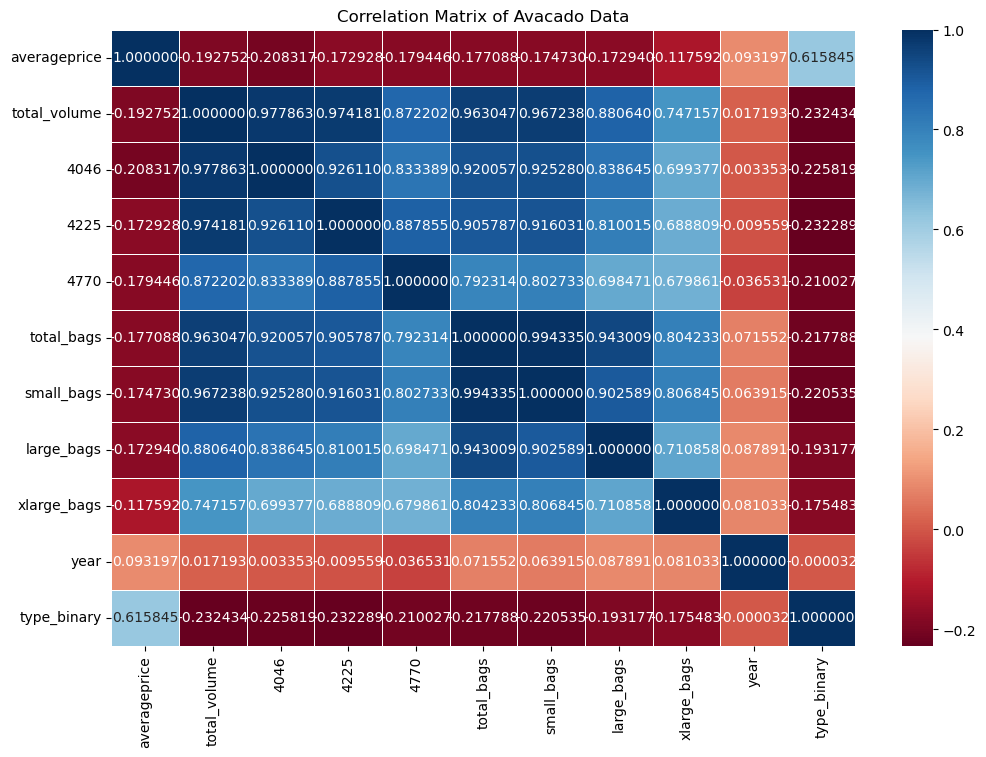

In [120]:
corr_all= avacado_2.corr(numeric_only = True)
plt.figure(figsize=(12,8))

sns.heatmap(corr_all, annot=True, cmap="RdBu", fmt="2f", linewidths=0.5)
plt.title("Correlation Matrix of Avacado Data")

plt.show()

In [121]:
avacado_2.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,type_binary
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,0
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,0
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,0
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,0
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,0


In [122]:
avacado_3= avacado_2.rename(columns= {"averageprice":"average_price"})

In [123]:
avacado_3.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,type_binary
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,0
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,0
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,0
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,0
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,0


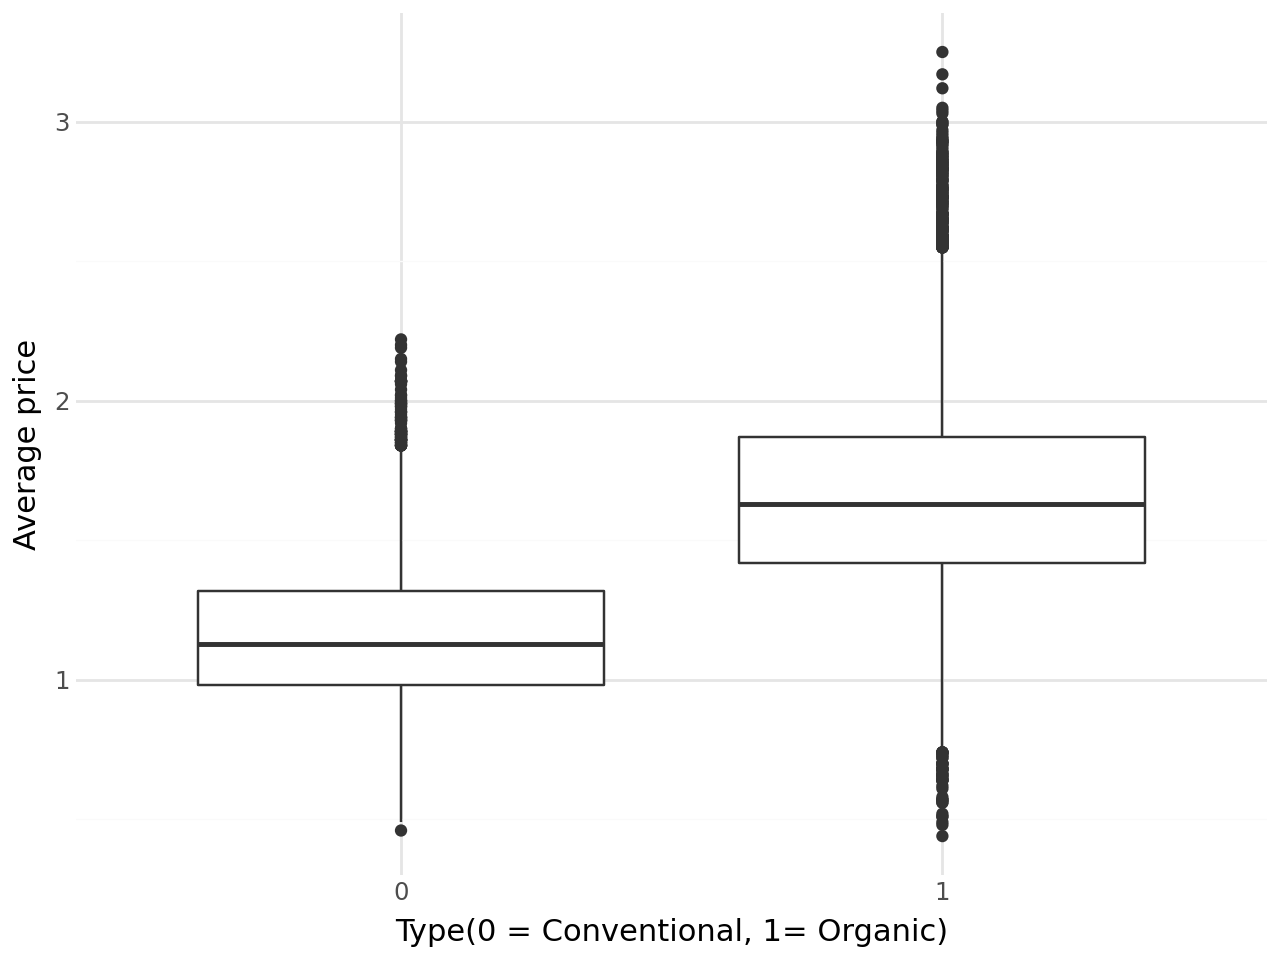

In [124]:
from plotnine import *
(ggplot(avacado_3, aes(x="factor(type_binary)", y="average_price"))
 +geom_boxplot()
 +labs(x= "Type(0 = Conventional, 1= Organic)", y="Average price")
 +theme_minimal())

In [125]:
#To investigate the relationship between avocado type and market price, a boxplot was generated. 
#The visualization reveals a distinct price premium for Organic avocados.
#Given that the median price for the Organic category sits entirely above the 75th percentile of the Conventional category,
#we can conclude that Type is a strong independent variable with a positive correlation to Average Price.

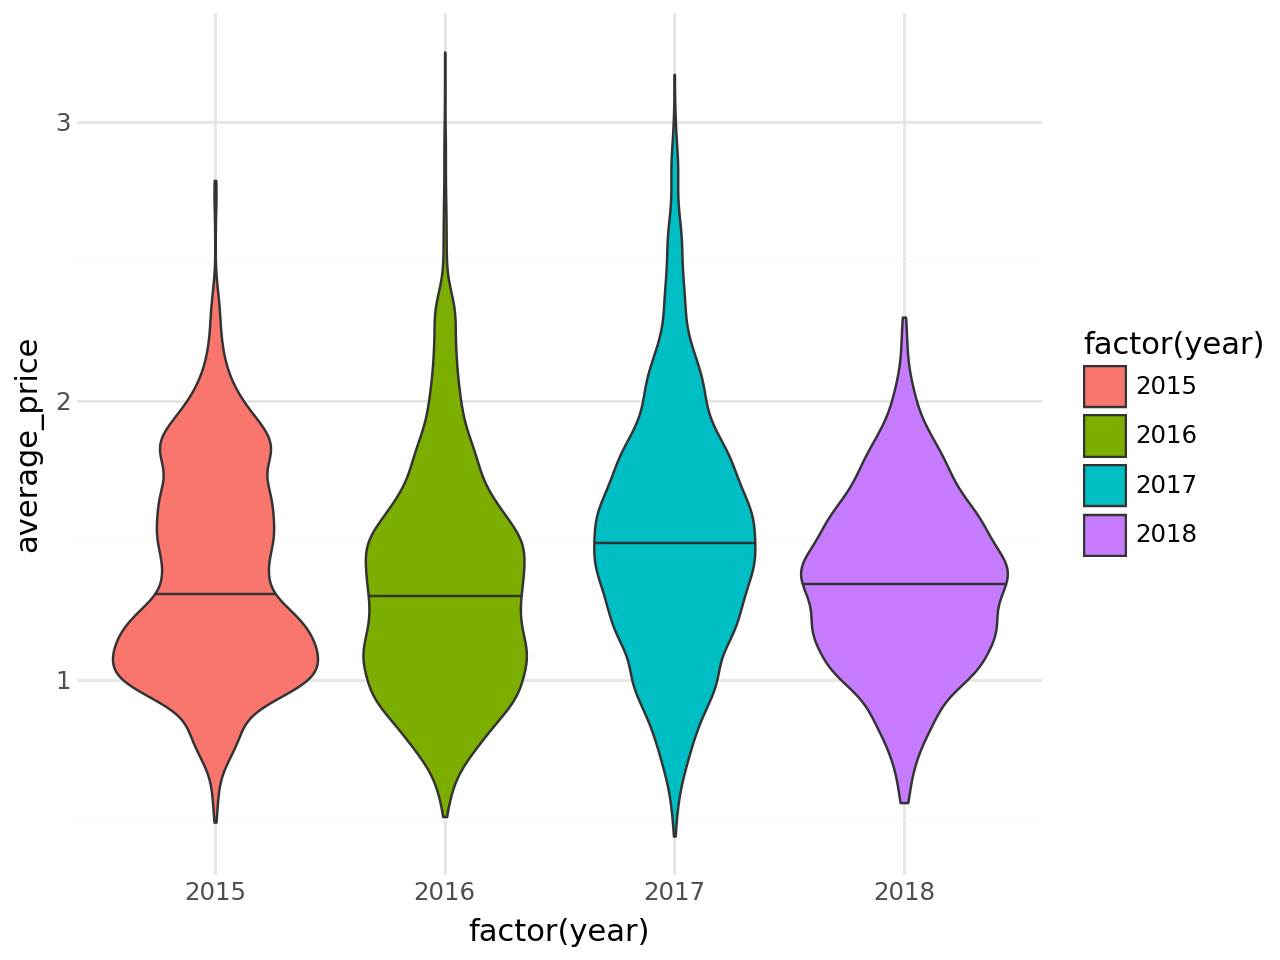

In [126]:
(ggplot(avacado_3, aes(x="factor(year)", y="average_price", fill="factor(year)"))
 +geom_violin(draw_quantiles=[0.5])
 +theme_minimal())

In [127]:
#The violin plot reveals that while avocado prices remained relatively stable between 2015 and 2016, 
#there was a significant upward shift in 2017. 
#This indicates that Year can act as an independent variable during specific periods of market volatility, 
#though it is generally less influential than Type

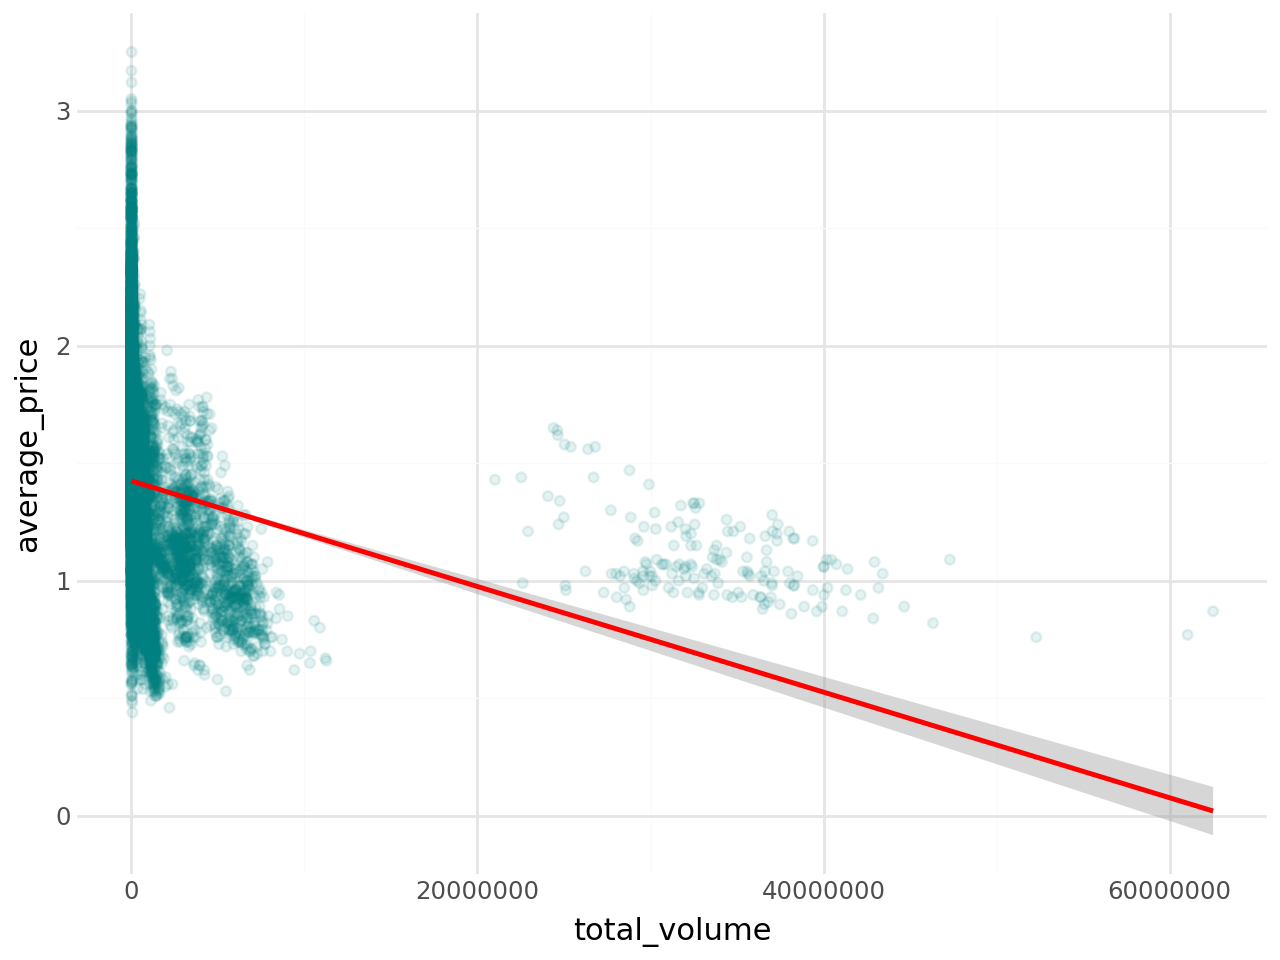

In [128]:
(ggplot(avacado_3, aes(x="total_volume", y = "average_price"))
 +geom_point(alpha=0.1, color= "teal")
 +geom_smooth(method='lm', color='red')
 +theme_minimal())

In [129]:
#The scatter plot confirms a negative linear relationship between Total Volume and Average Price. 
#The downward-sloping regression line illustrates the law of supply and demand: as market volume increases, price consistently decreases.
#Furthermore, the high density of points at lower volumes suggests that while volume is a key independent variable,
#price volatility is highest when supply is limited

In [130]:
# I choose total volume, type and year as my independent variavles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Define Independent (X) and Dependent (y) variables
X = avacado_3[['total_volume', 'type_binary', 'year']]
y = avacado_3['average_price']

# Step 2: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the model
model_3_features= LinearRegression()
model_3_features.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [131]:
model_3_features.intercept_

np.float64(-75.80103769115972)

In [132]:
pd.DataFrame(model_3_features.coef_, X_train.columns, ["Coefficient"])

,Coefficient
total_volume,-6.349042e-09
type_binary,4.887030e-01
year,3.817533e-02


average_price = -75.80 + 0.49*type_binary + ).038*year - 0.000000006*total_volume
this means that for every unit increase in the trype of avacado, average price increase by 0.49 units
and unit increase in year increases average price by 0.38
lastly, a unit increase in total volume decreases the average price by 0.000000006 units

In [133]:
  from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [134]:
average_price_pred1= model_3_features.predict(X_train)

In [135]:
average_price_pred1[:20]

array([1.68727864, 1.15676077, 1.64909636, 1.12133433, 1.64888008,
       1.19685471, 1.61094684, 1.15854916, 1.1210291 , 1.15860043,
       1.10888905, 1.12023052, 1.64912237, 1.61094498, 1.17551686,
       1.61087081, 1.19821946, 1.68680869, 1.61081736, 1.64893137])

In [136]:
R2= r2_score(y_train, average_price_pred1)
R2

0.39401139973243204

In [137]:
mse = mean_squared_error(y_train, average_price_pred1)
print(f"MSE is {mse}")

rmse = np.sqrt(mse)
print(f"RMSE is {rmse}")

mae = mean_absolute_error(y_train, average_price_pred1)
print(f"MAE is {mae}")

r2 =r2_score(y_train,average_price_pred1)
print(f"R2 is {r2}")

residuals = y_train - average_price_pred1
print(f"Residuals is {residuals}")


MSE is 0.09847369498543354
RMSE is 0.3138051863584054
MAE is 0.2409726584662595
R2 is 0.39401139973243204
Residuals is 16391    0.192721
4990    -0.346761
13653    0.360904
2074    -0.101334
12377   -0.118880
           ...   
11284   -0.060880
11964   -0.099130
5390     0.150095
860      0.009503
15795   -0.337290
Name: average_price, Length: 14599, dtype: float64


The model achieved an R-squared of 0.394, indicating that the independent variables (Type, Volume, and Year) account for nearly 40% of the price variance. This is quite a fair percentage of accuracy. the mae and rsme are low and this is good. Furthermore, the balanced distribution of residuals suggests that the linear model is unbiased. Also, seeing that my residuals are not close to 1 I am encouraged.

In [138]:
# 1. Calculate the mean price for every region
region_means = avacado_3.groupby('region')['average_price'].mean()

# 2. Map those means to a new numerical column
avacado_3['region_numeric'] = avacado_3['region'].map(region_means)

# Check the first few rows to see the new numbers
print(avacado_3[['region', 'region_numeric']].head())

   region  region_numeric
0  Albany        1.561036
1  Albany        1.561036
2  Albany        1.561036
3  Albany        1.561036
4  Albany        1.561036


In [139]:

X = avacado_3[['total_volume', 'type_binary', 'year', 'region_numeric']]
y = avacado_3['average_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_with_region = LinearRegression()
model_with_region.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [140]:
model_with_region.intercept_

np.float64(-78.48235995245105)

In [141]:
pd.DataFrame(model_with_region.coef_, X_train.columns, ["Coefficient"])

,Coefficient
total_volume,-1.604052e-09
type_binary,4.942810e-01
year,3.880902e-02
region_numeric,9.941943e-01


Price = -78.482 + 0.494*type_binary + 0.0994*region_numeric +0.0388*year -0.0000000016*total_volume

In [142]:
train_preds = model_with_region.predict(X_train)
print(f"New Training R2 Score: {r2_score(y_train, train_preds):.4f}")

New Training R2 Score: 0.5584


In [143]:
mse = mean_squared_error(y_train, train_preds)
print(f"MSE is {mse}")

rmse = np.sqrt(mse)
print(f"RMSE is {rmse}")

mae = mean_absolute_error(y_train, train_preds)
print(f"MAE is {mae}")

r2 =r2_score(y_train,train_preds)
print(f"R2 is {r2}")

residuals = y_train - train_preds
print(f"Residuals is {residuals}")

MSE is 0.07176230891444892
RMSE is 0.2678848799660946
MAE is 0.20051740026149623
R2 is 0.558388246348749
Residuals is 16391    0.092827
4990    -0.335744
13653    0.541777
2074     0.061735
12377   -0.268577
           ...   
11284   -0.052123
11964   -0.252875
5390     0.042011
860     -0.091868
15795   -0.246073
Name: average_price, Length: 14599, dtype: float64


In [144]:
# 1. Generate predictions using the TEST set
test_preds = model_with_region.predict(X_test)

# 2. Calculate the final "Official" Metrics
final_r2 = r2_score(y_test, test_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
final_mae = mean_absolute_error(y_test, test_preds)

print(f"--- FINAL TEST RESULTS ---")
print(f"Final R2 Score: {final_r2:.4f}")
print(f"Final RMSE: {final_rmse:.4f}")
print(f"Final MAE: {final_mae:.4f}")

--- FINAL TEST RESULTS ---
Final R2 Score: 0.5472
Final RMSE: 0.2697
Final MAE: 0.2031


The model achieved an accuracy of 54% and this is good. Also, the rsme, mae are low values, increasing confidence in 
the model.

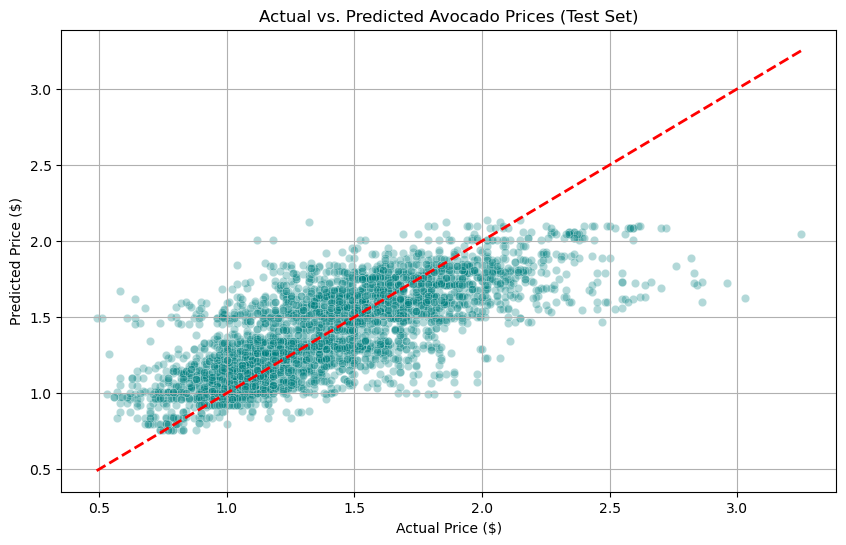

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plotting Actual vs Predicted
sns.scatterplot(x=y_test, y=test_preds, alpha=0.3, color='teal')

# The "Perfect Prediction" Line (Where Actual = Predicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted Avocado Prices (Test Set)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True)
plt.show()

The data points show a strong positive correlation, clustering closely around the dashed red identity line. This indicates that the model is effective at capturing the general price trends based on the input features. There are a few outliers but overall, our model is doing a good job.

LOGISTIC REGRESSION

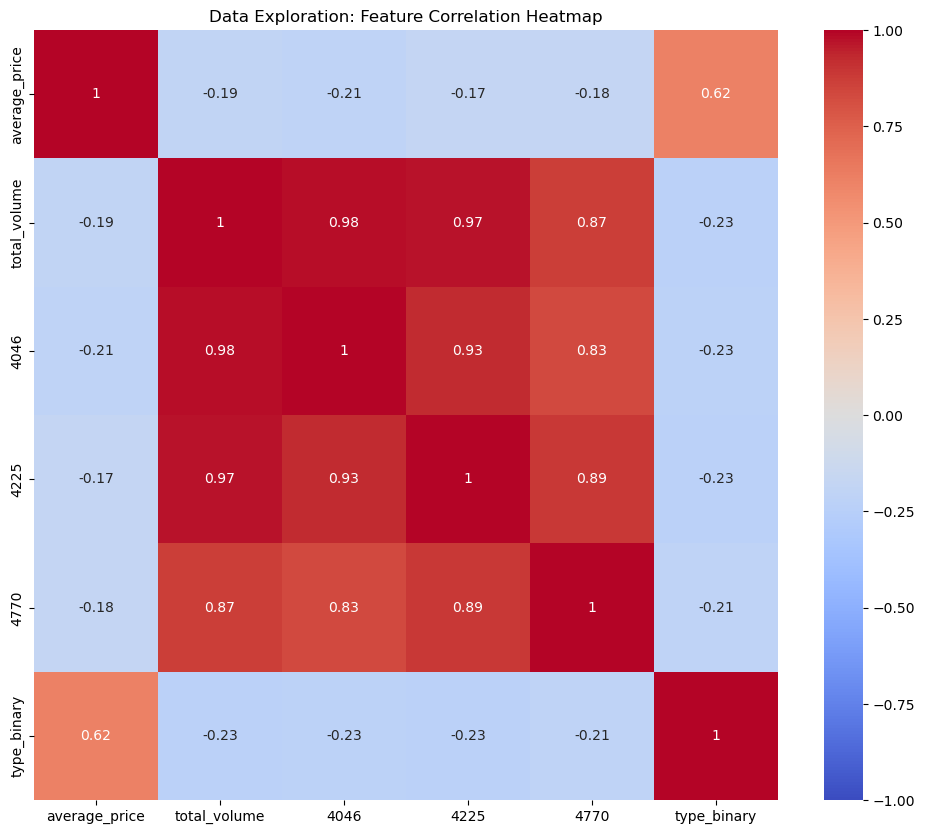

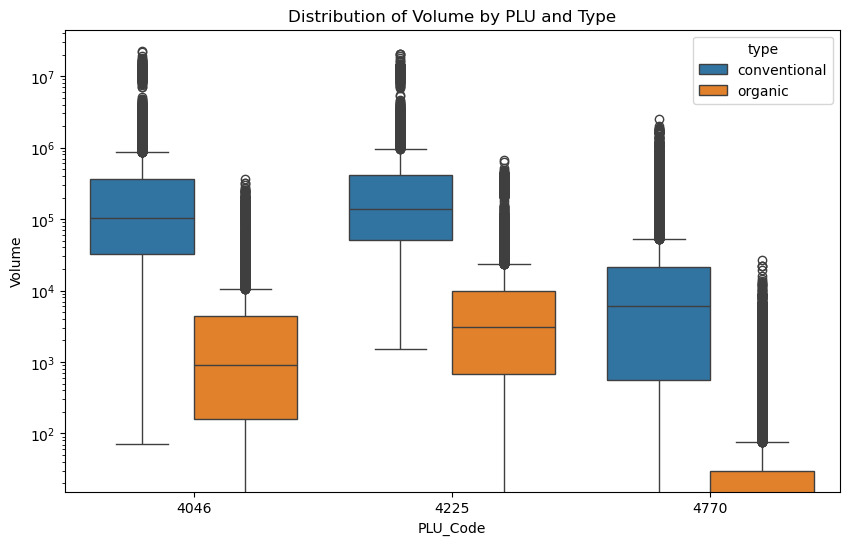

In [146]:
# --- Step 1: Correlation Matrix (Identifying Multicollinearity) ---
plt.figure(figsize=(12, 10))
# We check all numerical clues to prove the 0.9 correlation problem
cols_for_heatmap = ['average_price', 'total_volume', '4046', '4225', '4770', 'type_binary']
sns.heatmap(avacado_3[cols_for_heatmap].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Data Exploration: Feature Correlation Heatmap")
plt.show()

# --- Step 2: Pivot Longer & Visualization
# Pivoting PLU codes to compare their distributions side-by-side
avacado_long = avacado_3.melt(id_vars=['type'],
                              value_vars=['4046', '4225', '4770'],
                              var_name='PLU_Code',
                              value_name='Volume')

plt.figure(figsize=(10, 6))
sns.boxplot(data=avacado_long, x='PLU_Code', y='Volume', hue='type')
plt.yscale('log') # Essential for massive volume ranges
plt.title("Distribution of Volume by PLU and Type")
plt.show()

To visualize the structural differences between Conventional and Organic avocados, a grouped boxplot was generated for the PLU codes (4046, 4225, 4770).Due to the massive variance in sales volume—where Conventional units often reach into the millions 
while Organic units remain in the thousands—a logarithmic scale (Base 10) was applied to the Y-axis.

The boxplot analysis reveals a clear separation in volume distributions.
Conventional avocados consistently operate at a scale 10 to 100 times larger than Organic. 
Specifically, the near-absence of Organic sales in the PLU 4770 category provides a distinct structural fingerprint
that the Logistic Regression model can exploit for high classification accuracy

In [147]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# 1. Define Features and Target
X = avacado_3[['average_price', 'total_volume', '4046', '4225', '4770']] 
y = avacado_3['type_binary']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the RAW model 
log_raw = LogisticRegression()
log_raw.fit(X_train, y_train)
print("Initial 'Raw' Model trained successfully.")

Initial 'Raw' Model trained successfully.


C:\Users\nmesoma\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [150]:
# 4. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit(X_train)
X_train_scaled



,copy,True
,with_mean,True
,with_std,True


In [151]:
X_standard_transform = X_train_scaled.transform(X_train)

X_standard_df = pd.DataFrame(X_standard_transform, columns = X_train.columns)

X_standard_df.head()

,average_price,total_volume,4046,4225,4770
0,1.178674,-0.247683,-0.235928,-0.245519,-0.211662
1,-1.475662,-0.079312,-0.110923,-0.118244,-0.011670
2,1.501164,-0.247362,-0.234417,-0.244132,-0.211662
3,-0.954717,-0.206482,-0.173141,-0.213823,-0.210415
4,0.310433,-0.237356,-0.235916,-0.213896,-0.211662


In [152]:
X_test_scaled = scaler.transform(X_test)

In [154]:
# 5. Train the final 'Standardized' model
model_1= LogisticRegression()
model_1.fit(X_standard_df, y_train)
print("Standardized Model trained successfully.")

Standardized Model trained successfully.


In [155]:
model_1.intercept_

array([-7.88829599])

In [156]:
model_1.coef_

array([[  1.61590994,  -2.40958865, -13.55863003, -12.89545187,
        -12.18987777]])

In [158]:
lr = pd.DataFrame(model_1.coef_.T, X_standard_df.columns, columns = ["Coefficient"])
lr

,Coefficient
average_price,1.615910
total_volume,-2.409589
4046,-13.558630
4225,-12.895452
4770,-12.189878


In [159]:
lr = pd.DataFrame(np.exp(model_1.coef_), columns =  X_standard_df.columns)

lr

,average_price,total_volume,4046,4225,4770
0,5.032465,0.089852,0.000001,0.000003,0.000005


What the Model Is Predicting

1 → increases odds of organic (1)

< 1 → decreases odds of organic → increases likelihood of conventional (0)

≈ 1 → little or no effect

Since the target is:

0 = conventional

1 = organic

The model is predicting the odds of being organic

Interpretation
For every $1 increase in average price, the avocado is more than 5 times more likely to be Organic.
This also indicates that as the total volume of avocados sold increases, the likelihood of the avocado being organic decreases dramatically. In other words, high-volume sales are heavily associated with conventional avocados.
The coefficients of the PLU codes suggest that as the volume of these specific product sizes increases, the probability of the avocado being organic drops to nearly zero. These specific PLU codes are almost exclusively indicators for Conventional avocado varieties.


--- Training Set Performance ---
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      7306
           1       0.89      0.93      0.91      7293

    accuracy                           0.91     14599
   macro avg       0.91      0.91      0.91     14599
weighted avg       0.91      0.91      0.91     14599



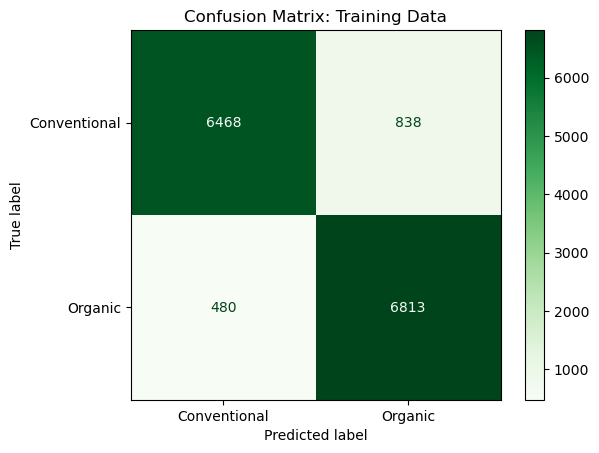

In [161]:
# 7. Predict on Training Data
train_predictions = model_1.predict(X_standard_df)

# 8. Training Confusion Matrix
print("\n--- Training Set Performance ---")
print(classification_report(y_train, train_predictions))

cm_train = confusion_matrix(y_train, train_predictions)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Conventional', 'Organic'])
disp_train.plot(cmap='Greens')
plt.title("Confusion Matrix: Training Data")
plt.show()

The model achieved an accuracy of approximately 91% on the training data. 
The confusion matrix shows that the model is slightly better at identifying Organic avocados (6,813 correct) than Conventional ones, 
but the overall error rate is low. With only a 9% total error rate, 
the features of Price and Volume have proven to be highly reliable predictors of avocado type

C:\Users\nmesoma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names



--- Final Test Set Performance ---
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1820
           1       0.89      0.94      0.91      1830

    accuracy                           0.91      3650
   macro avg       0.91      0.91      0.91      3650
weighted avg       0.91      0.91      0.91      3650



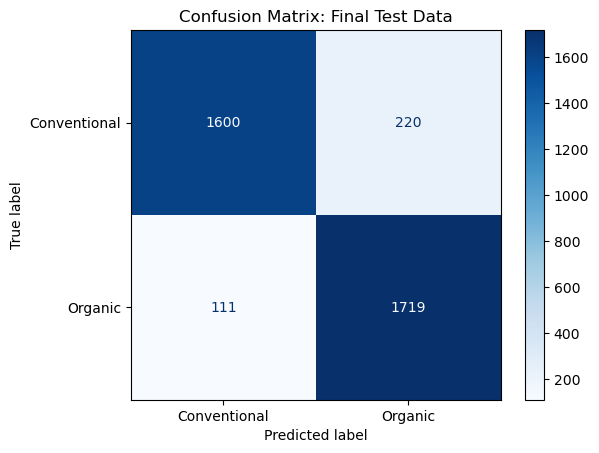

In [162]:
# 9. Predict on Test Data
test_predictions = model_1.predict(X_test_scaled)

print("\n--- Final Test Set Performance ---")
print(classification_report(y_test, test_predictions))

# Final Confusion Matrix
cm_test = confusion_matrix(y_test, test_predictions)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Conventional', 'Organic'])
disp_test.plot(cmap='Blues')
plt.title("Confusion Matrix: Final Test Data")
plt.show()

In [177]:
PCA 

sklearn.decomposition._pca.PCA

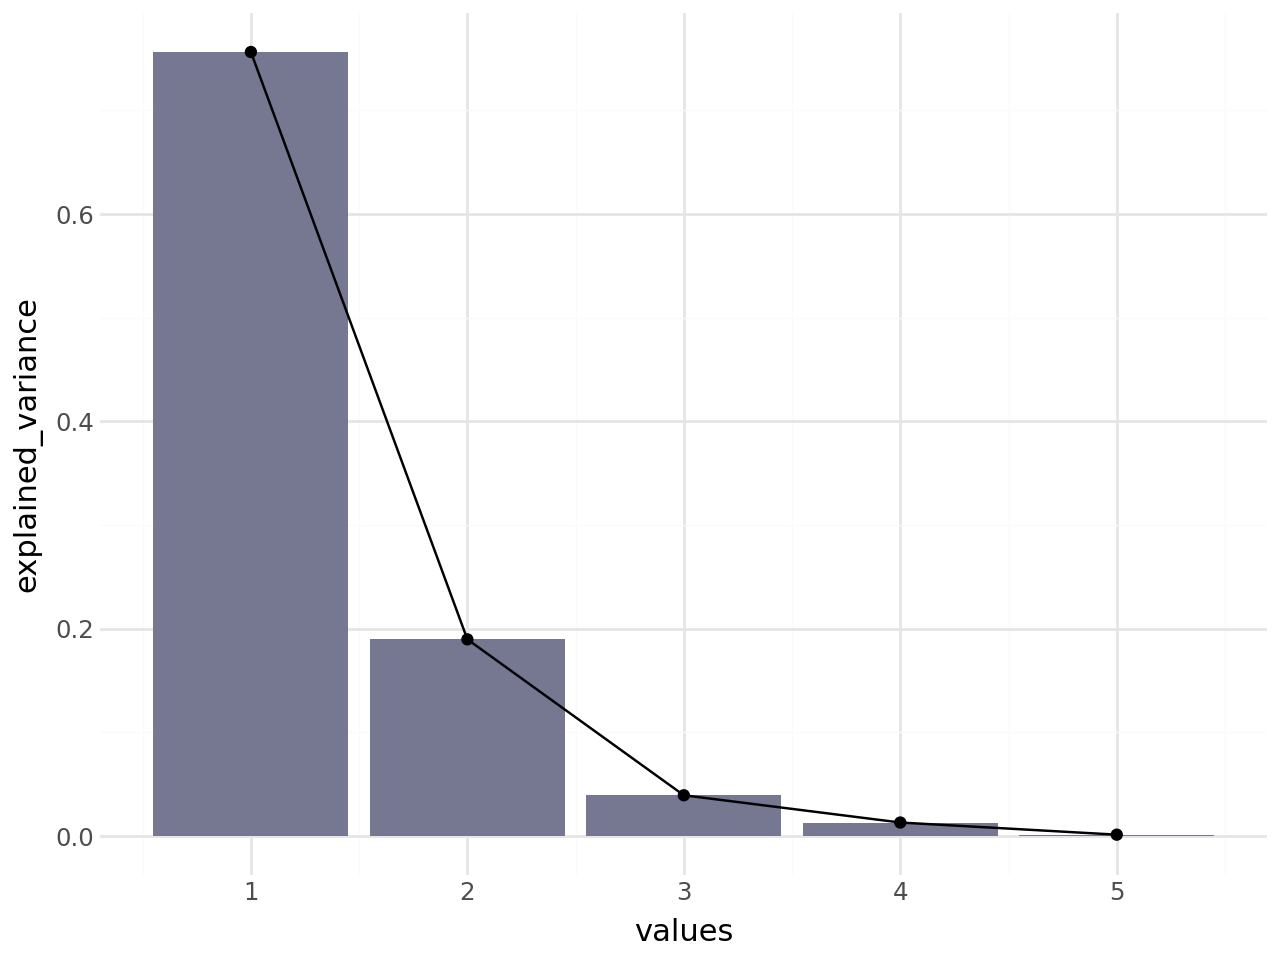

In [166]:
import pandas as pd
from plotnine import ggplot, aes, geom_col, geom_line, geom_point, theme_minimal
from sklearn.decomposition import PCA

# 1. Fit PCA on all features to see variance distribution
pca_full = PCA()
pca_full.fit(X_standard_df)

# 2. Create the dataframe for the plot 
explained_variance_df = pd.DataFrame({
    'values': range(1, len(pca_full.explained_variance_ratio_) + 1),
    'explained_variance': pca_full.explained_variance_ratio_
})

# 3. Plotting the Scree Plot
((ggplot(explained_variance_df, aes(x='values', y='explained_variance'))
    + geom_col(fill="#767791FF")
    + geom_line()
    + geom_point()
    + theme_minimal()))

Upon inspecting the Scree Plot, the 'elbow' is observed at 2 components, accounting for approximately 90% of the variance. However, to ensure maximum predictive power 3 principal components were selected using the cumulative variance threshold. This captures nearly all the information while still reducing the feature set from 5 variables down to 3.

In [167]:
# 4. Initialize and fit PCA with 3 components
pca_3 = PCA(n_components=3)
X_train_pca = pca_3.fit_transform(X_standard_df)
X_test_pca = pca_3.transform(X_test_scaled)

print(f"Original shape: {X_standard_df.shape}")
print(f"PCA shape: {X_train_pca.shape}")

Original shape: (14599, 5)
PCA shape: (14599, 3)


C:\Users\nmesoma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names


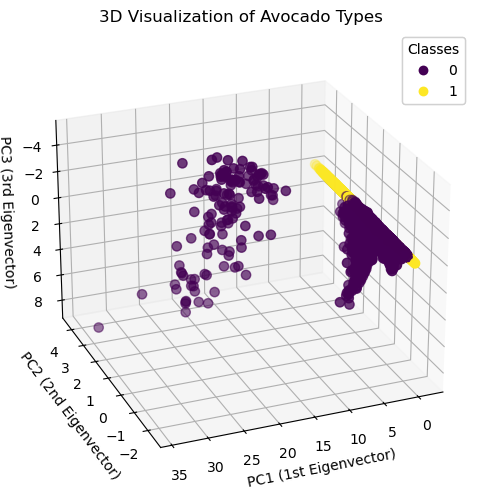

In [169]:
import matplotlib.pyplot as plt

# 5. Create 3D Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d', elev=-155, azim=112)

# Color the points by Type (0=Conventional, 1=Organic)
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2],
                     c=y_train, s=45, cmap='viridis')

ax.set_xlabel("PC1 (1st Eigenvector)")
ax.set_ylabel("PC2 (2nd Eigenvector)")
ax.set_zlabel("PC3 (3rd Eigenvector)")
ax.set_title("3D Visualization of Avocado Types")

# Add the legend 
legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
ax.add_artist(legend1)

plt.show()

The 3D scatter plot confirms that reducing the dataset to three principal components successfully preserves the "signal" needed for classification. The two avocado types form distinct, separate clusters in the 3D space, proving that the PCA has captured the core differences between Conventional and Organic pricing and volume patterns. Because the classes are so clearly partitioned, we can conclude that the redundant PLU variables were successfully consolidated without losing the structural integrity of the data.

In [173]:
# Create a DataFrame for the PCA components
X_pca_df = pd.DataFrame(X_train_pca, columns=['pca_1', 'pca_2', 'pca_3'])

# Initialize and fit the model
model = LogisticRegression()
model.fit(X_pca_df, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [171]:
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

# Converting log-odds to odds ratio
print(f"Odds Ratios: {np.exp(model.coef_)}")

Intercept: [-7.67059158]
Coefficients: [[-19.93906759  -1.12306443  -2.19651387]]
Odds Ratios: [[2.19064989e-09 3.25281465e-01 1.11190107e-01]]


--- Training Data Evaluation (After PCA) ---
              precision    recall  f1-score   support

           0       0.93      0.88      0.91      7306
           1       0.89      0.93      0.91      7293

    accuracy                           0.91     14599
   macro avg       0.91      0.91      0.91     14599
weighted avg       0.91      0.91      0.91     14599



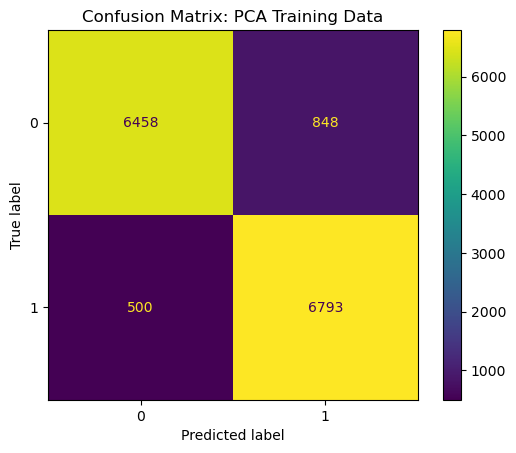

In [174]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Predict on training data
X_pred = model.predict(X_pca_df)

# Print Classification Report
print("--- Training Data Evaluation (After PCA) ---")
print(metrics.classification_report(y_train, X_pred))

# Plot Confusion Matrix
metrics.ConfusionMatrixDisplay.from_predictions(y_train, X_pred)
plt.title("Confusion Matrix: PCA Training Data")
plt.show()

--- Final Test Data Evaluation (After PCA) ---
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1820
           1       0.89      0.94      0.91      1830

    accuracy                           0.91      3650
   macro avg       0.91      0.91      0.91      3650
weighted avg       0.91      0.91      0.91      3650



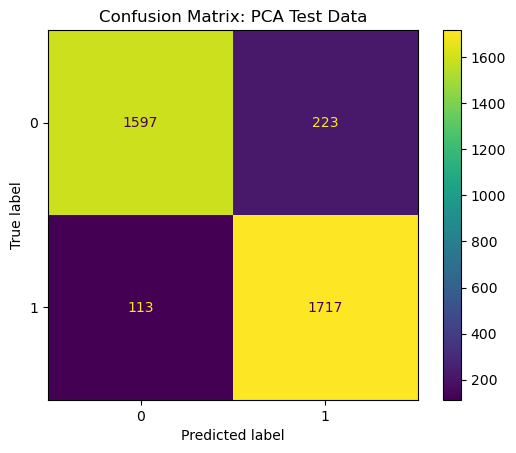

In [176]:
# 1. Ensure test data is in the PCA format
X_pca_test_df = pd.DataFrame(X_test_pca, columns=['pca_1', 'pca_2', 'pca_3'])

# 2. Predict on the test set
y_predictions = model.predict(X_pca_test_df)

# 3. Final Classification Report (Screenshot [46])
print("--- Final Test Data Evaluation (After PCA) ---")
print(metrics.classification_report(y_test, y_predictions))

# 4. Final Confusion Matrix 
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)
plt.title("Confusion Matrix: PCA Test Data")
plt.show()

While the 'Before PCA' model utilized the full suite of five features to achieve its results, the 'After PCA' model achieved a matching 91% accuracy using only three principal components. This is a significant finding: it demonstrates that 40% of the original data was redundant or 'noise.' By using PCA, we have created a more efficient, leaner model that maintains high predictive power with less computational complexity. The fact that the test accuracy (91%) matches the training accuracy further proves that our PCA-reduced model is robust and not overfitting.

Our group preers the PCA.